# Yelp Review Prediction - 90D1Y PRECOVID (Template Import)

This notebook imports functions from `prediction_template.ipynb` and runs the full pipeline with COVID settings.

This script examines whether early Yelp reviews predict future business ratings for the year 2015 with an early review window of 90 days.

It analyzes business-level early review features, including early average star rating, review count, reviewer bias, review word count, and reviewer profile metrics. 
The script evaluates how strongly each feature is associated with future average rating using the Pearson correlation coefficient, and then uses these features to build predictive regression models.

The script trains and compares baseline mean, linear regression, ridge regression, random forest, and XGBoost models. Model performance is evaluated using MAE, RMSE, R², and 5-fold cross-validation.

Input:
	Processed CSV file with one row per review.

Output:
	Model comparison results and correlation visualizations.

Results:
	Early average stars had the highest Pearson Correlation Coefficient r = 0.714.
	Ridge model performed the best with r^2 =  0.499, mae = 0.339, and rmse = 0.442

In [7]:
from pathlib import Path

%run ./prediction_template.ipynb

PROCESSED_DIR = Path("./processed_data")
COHORT_YEAR = 2015 
EARLY_WINDOW_DAYS = 30 * 3
FUTURE_WINDOW_END_DAY = 365 * 2
MIN_EARLY_REVIEWS = 5
MIN_FUTURE_REVIEWS = 5
PERIOD = "PRECOVID"
FEATURE_FILE = "review_features.csv"

Sanity check report
Rows: 12818
Columns: 16
Features: 14
Missing features: 0
Duplicate business_id: 0
Missing target values: 0
Missing feature values: 0
Target summary:
count    12818.000000
mean         3.731813
std          0.709931
min          1.000000
25%          3.353786
50%          3.857143
75%          4.230769
max          5.000000
dtype: float64
Regression results
               model       mae      rmse        r2  n_train  n_test  \
0  linear_regression  0.373808  0.489071  0.513244    10254    2564   
1              ridge  0.373810  0.489070  0.513246    10254    2564   
2      random_forest  0.378021  0.496528  0.498288    10254    2564   
3            xgboost  0.381901  0.504572  0.481901    10254    2564   
4      baseline_mean  0.542708  0.701042 -0.000127    10254    2564   

   n_features  cv_mae_mean  cv_mae_std  cv_r2_mean  cv_r2_std  cv_folds_used  
0          14     0.379887    0.010152    0.508574   0.017970              5  
1          14     0.379894    0.0101

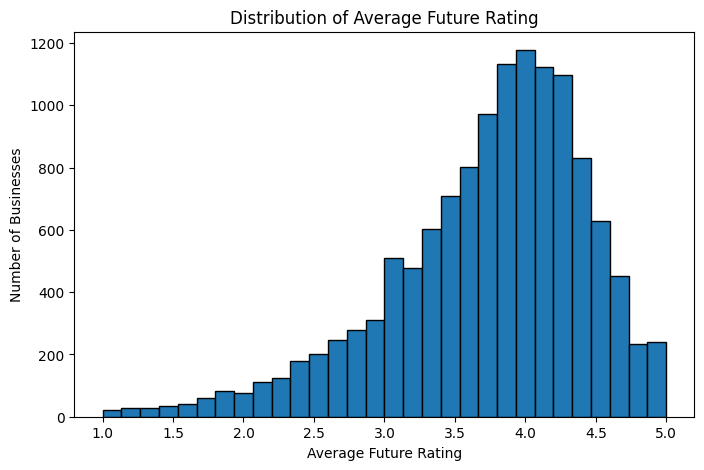

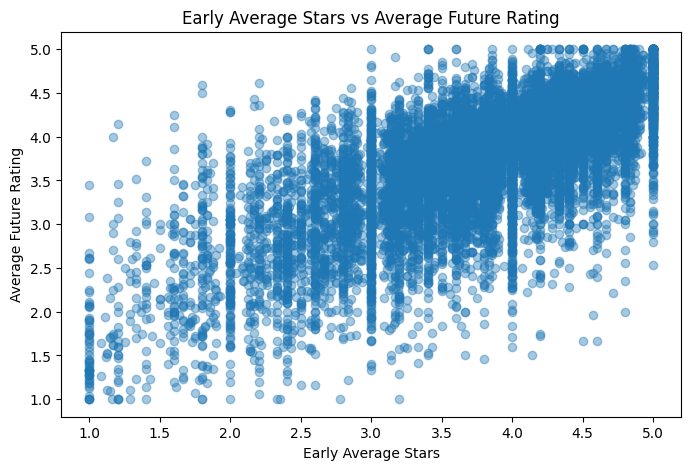

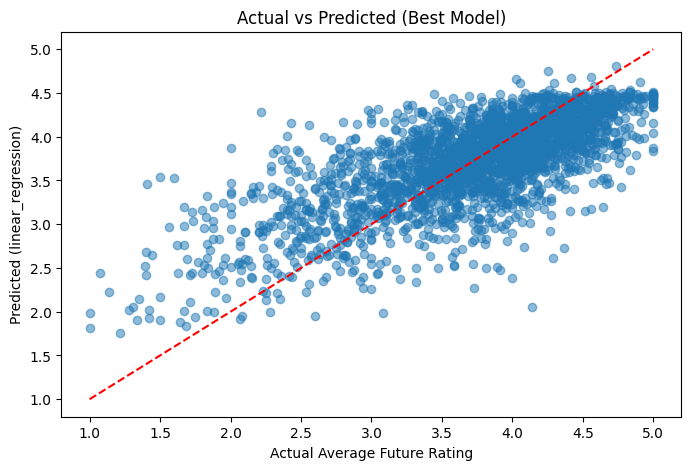

Best model: linear_regression
model            linear_regression
mae                       0.373808
rmse                      0.489071
r2                        0.513244
n_train                      10254
n_test                        2564
n_features                      14
cv_mae_mean               0.379887
cv_mae_std                0.010152
cv_r2_mean                0.508574
cv_r2_std                  0.01797
cv_folds_used                    5
Name: 0, dtype: object


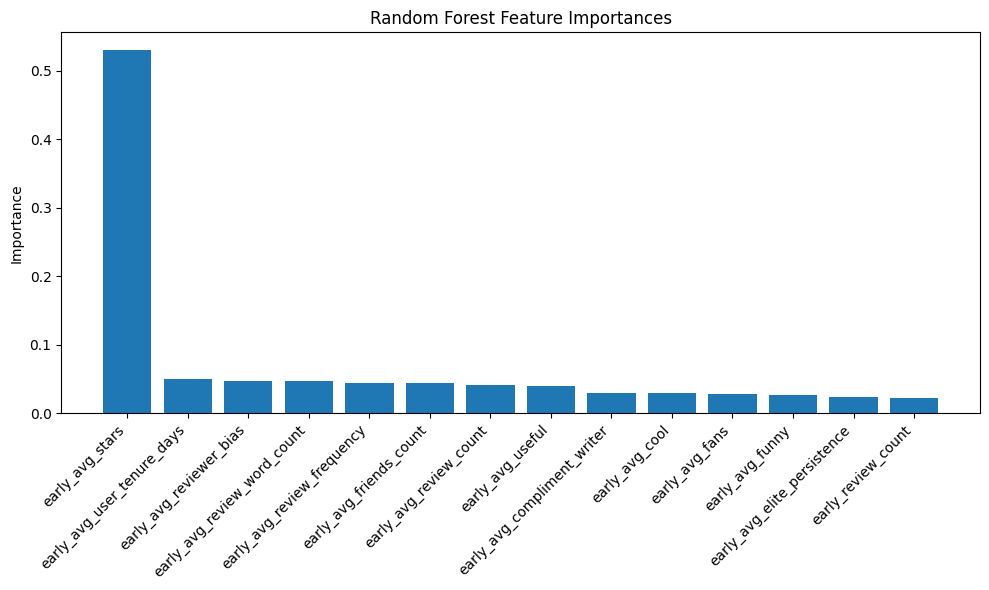

Top correlations with average_future_rating:


,feature,corr
0,early_avg_stars,0.710252
1,early_avg_reviewer_bias,0.645536
2,early_avg_user_tenure_days,0.164677
3,early_avg_cool,0.158325
4,early_avg_review_word_count,-0.147388
5,early_review_count,0.116848
6,early_avg_fans,0.088593
7,early_avg_elite_persistence,0.087284
8,early_avg_friends_count,0.075139
9,early_avg_useful,-0.060282


,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
10,--S43ruInmIsGrnnkmavRw,3.400000,1.000000,0.400000,0.400000,564.000000,285.200000,1741.800000,80.400000,-0.432000,1280.200000,5.200000,108.400000,24.000000,5,3.571429
22,-09Oc2D14vRnmirPh0vlXw,3.222222,0.222222,0.111111,0.111111,37.111111,2.000000,62.000000,0.555556,-0.178889,579.666667,0.111111,48.222222,5.000000,9,2.714286
29,-0TffRSXXIlBYVbb5AwfTg,4.105263,0.815789,0.052632,0.394737,134.236842,8.947368,107.342105,3.052632,0.152368,1003.394737,1.421053,112.684211,27.447368,38,4.311538
37,-0iIxySkp97WNlwK66OGWg,4.304348,2.130435,0.608696,1.565217,113.000000,10.826087,200.086957,14.173913,0.211304,999.173913,1.695652,90.043478,26.260870,23,3.658228
44,-1B9pP_CrRBJYPICE5WbRA,3.718750,0.125000,0.031250,0.031250,80.625000,3.531250,59.593750,1.093750,-0.215000,1039.343750,0.437500,81.218750,19.343750,32,3.706587


In [8]:
pipeline_output = run_prediction_pipeline(
    processed_dir=PROCESSED_DIR,
    cohort_year=COHORT_YEAR,
    early_window_days=EARLY_WINDOW_DAYS,
    future_window_end_day=FUTURE_WINDOW_END_DAY,
    period=PERIOD,
    min_early_reviews=MIN_EARLY_REVIEWS,
    min_future_reviews=MIN_FUTURE_REVIEWS,
    feature_file=FEATURE_FILE,
)

model_df = pipeline_output["model_df"]
feature_cols = pipeline_output["feature_cols"]
target_col = pipeline_output["target_col"]

print("Model dataset shape:", model_df.shape)
print("Target column:", target_col)
print("Number of features:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])
print("Sanity report:", pipeline_output["sanity_report"])
print("Regression summary:")
print(pipeline_output["regression_report"]["results_df"])

output_dir = PROCESSED_DIR / "modeling_tables"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"business_level_{EARLY_WINDOW_DAYS}D_{FUTURE_WINDOW_END_DAY}D_{PERIOD}.csv"
model_df.to_csv(output_path, index=False, float_format="%.4f")
print("Saved modeling table to:", output_path.resolve())

results_package = generate_results_package(
    pipeline_output=pipeline_output,
    target_col=target_col,
    top_n_correlations=15,
    show_plots=True,
)

print("Top correlations with average_future_rating:")
display(results_package["correlation_table"])

model_df.head()

In [9]:
# Exploratory Tables and Graphs
# Summary stats, head, and missing values
import pandas as pd

print("Model dataset shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nSummary statistics:")
print(model_df.describe())

print("\nMissing values per column:")
print(model_df.isnull().sum())

print("\nFirst 5 rows:")
model_df.head()

Model dataset shape: (12818, 16)

Columns:
['business_id', 'early_avg_stars', 'early_avg_useful', 'early_avg_funny', 'early_avg_cool', 'early_avg_review_count', 'early_avg_fans', 'early_avg_friends_count', 'early_avg_compliment_writer', 'early_avg_reviewer_bias', 'early_avg_user_tenure_days', 'early_avg_elite_persistence', 'early_avg_review_word_count', 'early_avg_review_frequency', 'early_review_count', 'average_future_rating']

Summary statistics:
       early_avg_stars  early_avg_useful  early_avg_funny  early_avg_cool  \
count     12818.000000      12818.000000     12818.000000    12818.000000   
mean          3.781815          1.289485         0.346343        0.472507   
std           0.808462          1.490384         0.490120        0.849980   
min           1.000000          0.000000         0.000000        0.000000   
25%           3.333333          0.500000         0.000000        0.100000   
50%           3.909091          0.928571         0.200000        0.272727   
75%    

,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
10,--S43ruInmIsGrnnkmavRw,3.400000,1.000000,0.400000,0.400000,564.000000,285.200000,1741.800000,80.400000,-0.432000,1280.200000,5.200000,108.400000,24.000000,5,3.571429
22,-09Oc2D14vRnmirPh0vlXw,3.222222,0.222222,0.111111,0.111111,37.111111,2.000000,62.000000,0.555556,-0.178889,579.666667,0.111111,48.222222,5.000000,9,2.714286
29,-0TffRSXXIlBYVbb5AwfTg,4.105263,0.815789,0.052632,0.394737,134.236842,8.947368,107.342105,3.052632,0.152368,1003.394737,1.421053,112.684211,27.447368,38,4.311538
37,-0iIxySkp97WNlwK66OGWg,4.304348,2.130435,0.608696,1.565217,113.000000,10.826087,200.086957,14.173913,0.211304,999.173913,1.695652,90.043478,26.260870,23,3.658228
44,-1B9pP_CrRBJYPICE5WbRA,3.718750,0.125000,0.031250,0.031250,80.625000,3.531250,59.593750,1.093750,-0.215000,1039.343750,0.437500,81.218750,19.343750,32,3.706587


In [10]:
# Correlation with target: top features
numeric_cols = model_df.select_dtypes(include="number").columns.tolist()
if "average_future_rating" in numeric_cols:
    corr_series = model_df[numeric_cols].corr()["average_future_rating"].drop("average_future_rating")
    corr_top = corr_series.abs().sort_values(ascending=False).head(15)
    print("Top correlations with average_future_rating (by absolute value):")
    display(pd.DataFrame({"feature": corr_top.index, "corr": corr_top.values}))
else:
    print("average_future_rating not in numeric columns; skipping correlation summary.")

Top correlations with average_future_rating (by absolute value):


,feature,corr
0,early_avg_stars,0.710252
1,early_avg_reviewer_bias,0.645536
2,early_avg_user_tenure_days,0.164677
3,early_avg_cool,0.158325
4,early_avg_review_word_count,0.147388
5,early_review_count,0.116848
6,early_avg_fans,0.088593
7,early_avg_elite_persistence,0.087284
8,early_avg_friends_count,0.075139
9,early_avg_useful,0.060282


ALL MODEL RESULTS
               model       mae      rmse        r2  n_train  n_test  n_features  cv_mae_mean  cv_mae_std  cv_r2_mean  cv_r2_std  cv_folds_used
0  linear_regression  0.373808  0.489071  0.513244    10254    2564          14     0.379887    0.010152    0.508574   0.017970              5
1              ridge  0.373810  0.489070  0.513246    10254    2564          14     0.379894    0.010150    0.508574   0.017955              5
2      random_forest  0.378021  0.496528  0.498288    10254    2564          14     0.385170    0.011522    0.493626   0.017222              5
3            xgboost  0.381901  0.504572  0.481901    10254    2564          14     0.385631    0.011531    0.489347   0.017942              5
4      baseline_mean  0.542708  0.701042 -0.000127    10254    2564          14     0.554981    0.012607   -0.001461   0.000969              5



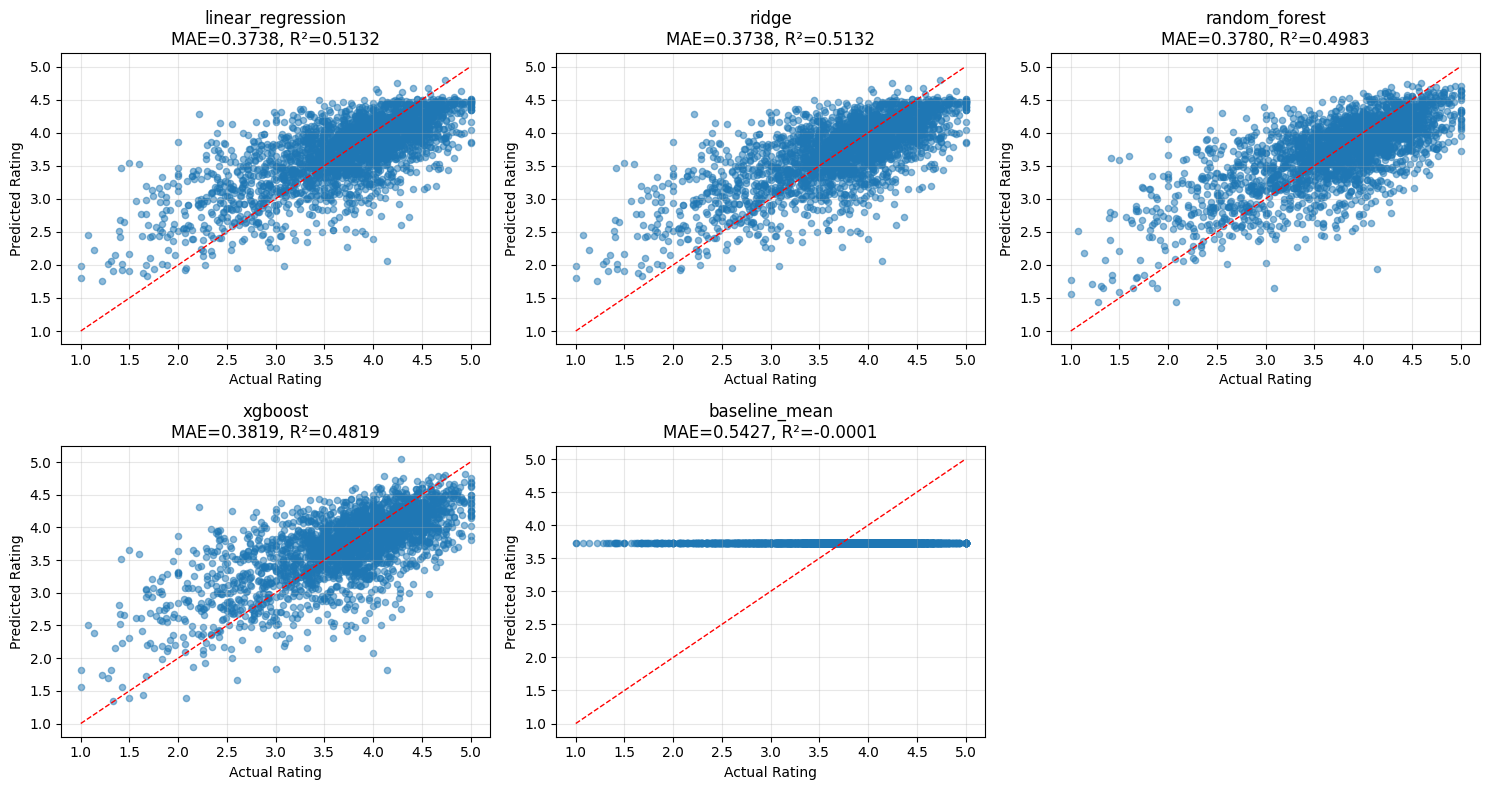

In [11]:
# Model Results: All models with predicted vs actual plots
import numpy as np

results_df = pipeline_output["regression_report"]["results_df"]
predictions_df = pipeline_output["regression_report"]["predictions_df"].copy()

print("=" * 80)
print("ALL MODEL RESULTS")
print("=" * 80)
print(results_df.to_string())
print()

y_true = predictions_df["average_future_rating"].values
min_val = float(y_true.min())
max_val = float(y_true.max())

# Plot predicted vs actual for each model
num_models = len(results_df)
n_cols = 3
n_rows = (num_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # flatten to 1D array for easier iteration

for idx, (_, row) in enumerate(results_df.iterrows()):
    model_name = row["model"]
    mae = row["mae"]
    r2 = row["r2"]
    
    # Get predictions for this model
    if model_name == "baseline_mean":
        pred_col = "pred_baseline_mean"
    else:
        pred_col = f"pred_{model_name}"
    
    if pred_col not in predictions_df.columns:
        print(f"Warning: {pred_col} not found in predictions_df")
        continue
    
    y_pred = predictions_df[pred_col].values
    
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.5, s=20)
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red", linewidth=1)
    ax.set_xlabel("Actual Rating")
    ax.set_ylabel("Predicted Rating")
    ax.set_title(f"{model_name}\nMAE={mae:.4f}, R²={r2:.4f}")
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(num_models, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


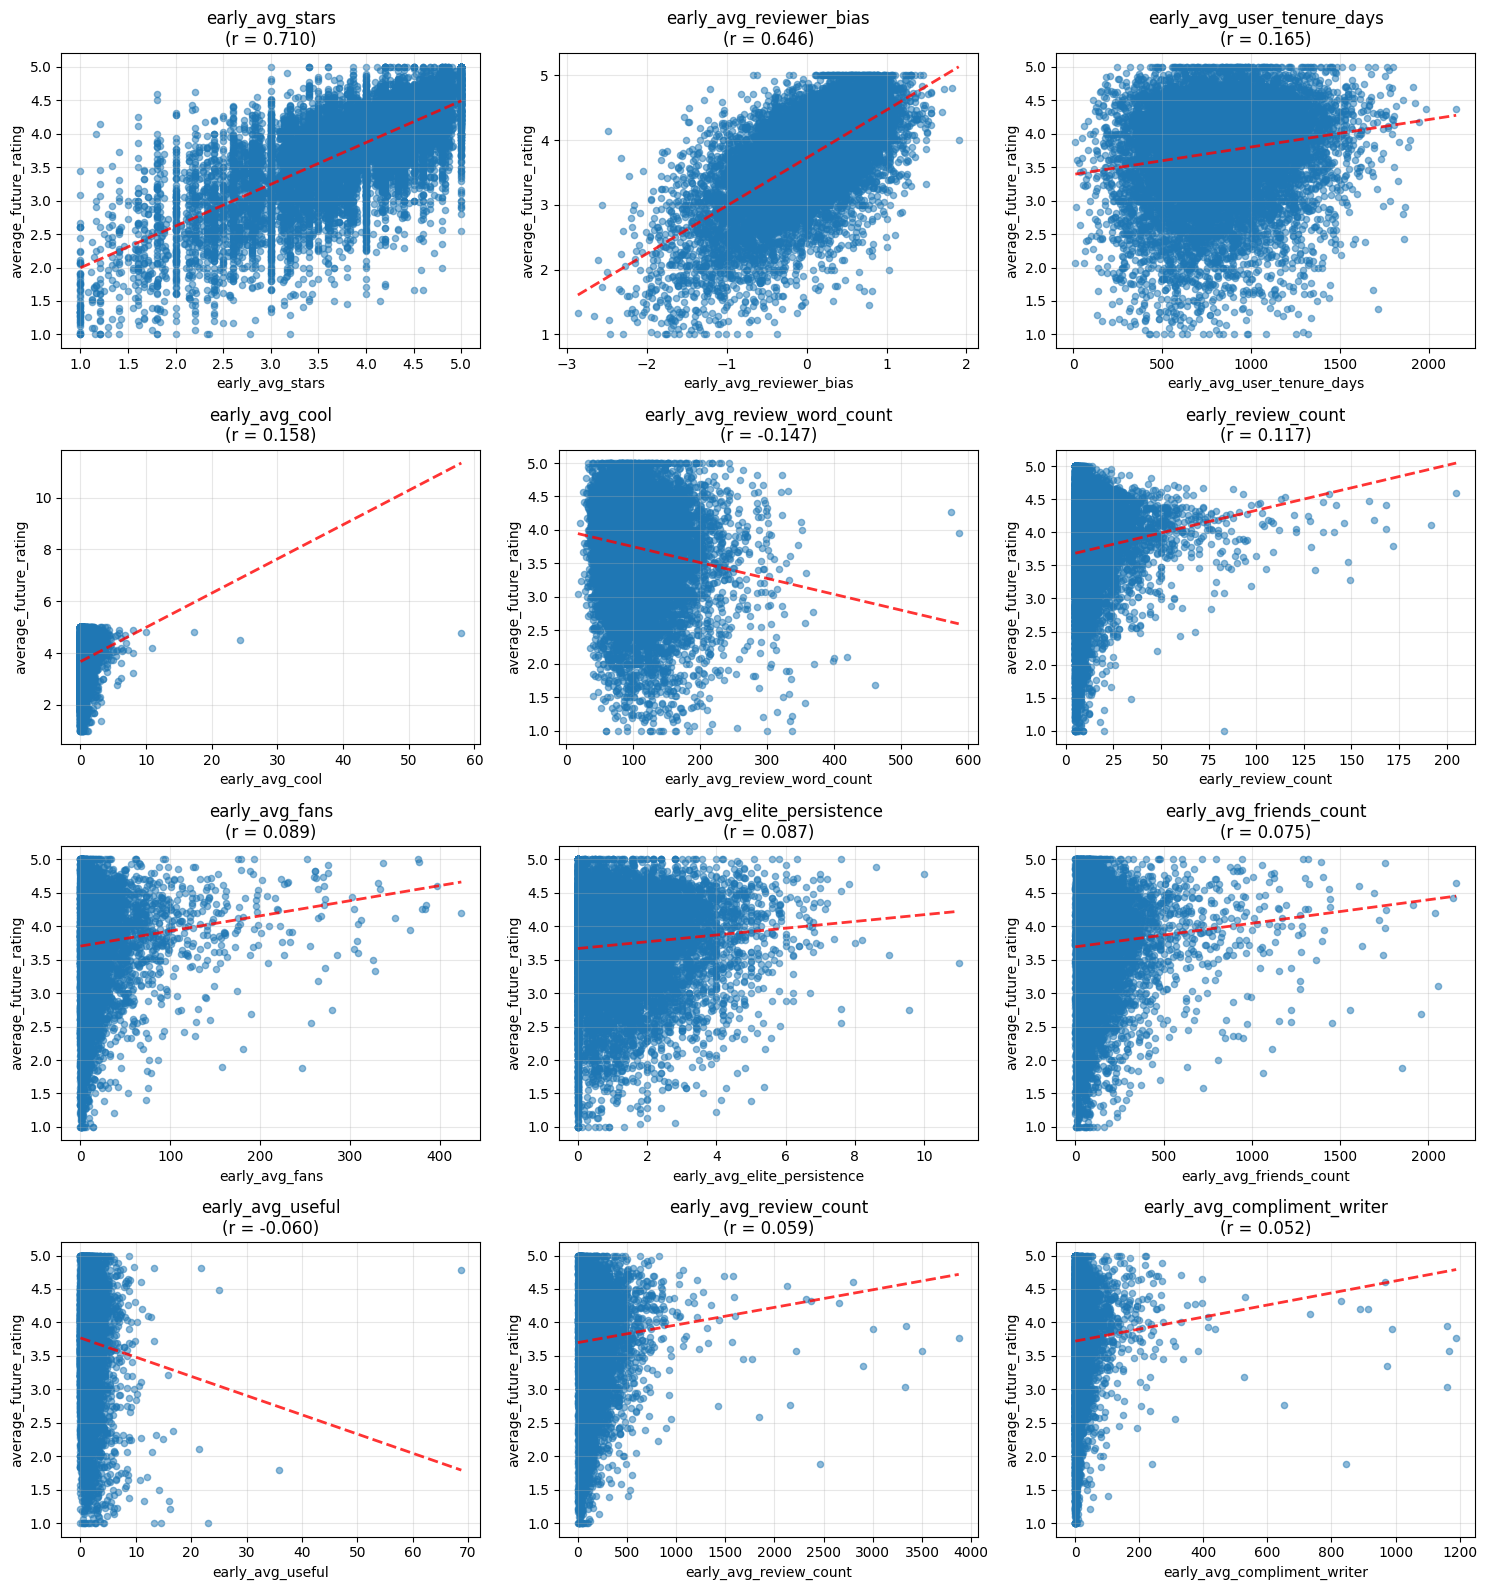

In [12]:
# Top Features vs Target Relationships
from scipy import stats

# Get top correlated features
numeric_cols = model_df.select_dtypes(include="number").columns.tolist()
if target_col in numeric_cols:
    corr_with_target = model_df[numeric_cols].corr()[target_col].drop(target_col)
    top_features = corr_with_target.abs().sort_values(ascending=False).head(12).index.tolist()
    
    # Create scatter plots for top features
    n_features = len(top_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for idx, feature in enumerate(top_features):
        ax = axes[idx]
        
        # Scatter plot
        ax.scatter(model_df[feature], model_df[target_col], alpha=0.5, s=20)
        
        # Add trend line
        z = np.polyfit(model_df[feature].dropna(), model_df[target_col].loc[model_df[feature].notna()], 1)
        p = np.poly1d(z)
        x_line = np.linspace(model_df[feature].min(), model_df[feature].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        # Calculate correlation
        corr_coef = corr_with_target[feature]
        
        ax.set_xlabel(feature)
        ax.set_ylabel(target_col)
        ax.set_title(f"{feature}\n(r = {corr_coef:.3f})")
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"{target_col} not in numeric columns; skipping feature vs target analysis.")
